## Workflow Structure

The notebook is organized as a sequential exploratory workflow:

1. environment setup
2. sequence and signal preparation
3. optimization of the core system
4. inspection of learning dynamics
5. reconstruction on a known example
6. generation from a new prompt


In [ ]:
from dataclasses import dataclass
from pathlib import Path
import math
import random
import importlib.util
import time

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(42)


@dataclass
class Config:
    project_dir: Path = Path(".")
    metadata_path: Path = project_dir / "metadata.csv"
    wav_dir: Path = project_dir / "golden_set"
    sample_rate: int = 22050
    n_fft: int = 1024
    hop_length: int = 256
    win_length: int = 1024
    n_mels: int = 80
    fmin: int = 0
    fmax: int = 8000

    hidden_size: int = 512
    encoder_dropout: float = 0.1
    decoder_layers: int = 6
    diffusion_steps: int = 50
    max_noise_level: float = 1.0
    min_noise_level: float = 0.05
    max_predicted_duration: int = 30

    batch_size: int = 64
    learning_rate: float = 1e-3
    epochs: int = 60
    duration_loss_weight: float = 0.05
    l2_loss_weight: float = 0.5
    prior_loss_weight: float = 1.0
    refinement_blend: float = 0.35
    loader_workers: int = 0
    batch_log_every: int = 1

    checkpoint_path: Path = project_dir / "compact_speech_pipeline.pt"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


config = Config(
    Path("datasets"), Path("datasets/metadata.csv"), Path("datasets/golden_set")
)
print(config)


Config(project_dir='datasets', metadata_path='datasets/metadata.csv', wav_dir='datasets/golden_set', sample_rate=22050, n_fft=1024, hop_length=256, win_length=1024, n_mels=80, fmin=0, fmax=8000, hidden_size=512, encoder_dropout=0.1, decoder_layers=6, diffusion_steps=50, max_noise_level=1.0, min_noise_level=0.05, max_predicted_duration=30, batch_size=64, learning_rate=0.001, epochs=60, duration_loss_weight=0.05, l2_loss_weight=0.5, prior_loss_weight=1.0, refinement_blend=0.35, loader_workers=0, batch_log_every=1, checkpoint_path=WindowsPath('compact_speech_pipeline.pt'), device='cuda')


## Starting Point

The workflow assumes paired text and speech are already available in the working environment.


In [2]:
REQUIRED_PACKAGES = [
    "torch",
    "torchaudio",
    "librosa",
    "soundfile",
    "pandas",
    "numpy",
    "matplotlib",
    "tqdm",
]
missing = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]
if missing:
    raise RuntimeError(
        f"Install missing packages first: pip install {' '.join(missing)}"
    )

assert config.metadata_path.exists(), config.metadata_path
assert config.wav_dir.exists(), config.wav_dir

AttributeError: 'str' object has no attribute 'exists'

## Data Preparation

A symbol-level representation is paired with observed timing information.

- text is converted into a sequence of symbols
- each recording is mapped into a compact spectral view
- token timing is inferred automatically from paired examples
- durations are projected onto frame space so the timing covers the full representation

This produces supervision tied to observed temporal structure rather than a uniform allocation of frames.


In [ ]:
def normalize_text(text: str) -> str:
    return " ".join(str(text).lower().strip().split())


class CharTokenizer:
    def __init__(self, texts):
        merged = "".join(texts)
        symbols = ["_"] + sorted(set(merged))
        if "?" not in symbols:
            symbols.append("?")
        self.pad_token = "_"
        self.unk_token = "?"
        self.symbol_to_id = {symbol: idx for idx, symbol in enumerate(symbols)}
        self.id_to_symbol = {idx: symbol for symbol, idx in self.symbol_to_id.items()}
        self.pad_id = self.symbol_to_id[self.pad_token]
        self.unk_id = self.symbol_to_id[self.unk_token]

    def encode(self, text: str):
        text = normalize_text(text)
        return [self.symbol_to_id.get(ch, self.unk_id) for ch in text]

    @property
    def vocab_size(self):
        return len(self.symbol_to_id)


ALIGNMENT_BUNDLE = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H
ALIGNMENT_LABELS = ALIGNMENT_BUNDLE.get_labels()
ALIGNMENT_DICT = {label: idx for idx, label in enumerate(ALIGNMENT_LABELS)}


def load_audio_mono(wav_path: Path) -> tuple[np.ndarray, int]:
    wav, sr = sf.read(wav_path)
    if wav.ndim == 2:
        wav = wav.mean(axis=1)
    return wav.astype(np.float32), sr


def resample_audio(wav: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    if orig_sr == target_sr:
        return wav.astype(np.float32)
    return librosa.resample(wav, orig_sr=orig_sr, target_sr=target_sr).astype(
        np.float32
    )


def extract_log_mel_from_waveform(wav: np.ndarray, config: Config) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=config.sample_rate,
        n_fft=config.n_fft,
        hop_length=config.hop_length,
        win_length=config.win_length,
        n_mels=config.n_mels,
        fmin=config.fmin,
        fmax=config.fmax,
        power=2.0,
    )
    return np.log(np.clip(mel, 1e-5, None)).T.astype(np.float32)


def build_alignment_targets(text: str) -> tuple[list[int], list[int]]:
    token_ids = []
    text_positions = []
    for idx, ch in enumerate(normalize_text(text)):
        if ch == " " and "|" in ALIGNMENT_DICT:
            token_ids.append(ALIGNMENT_DICT["|"])
            text_positions.append(idx)
            continue

        token = ch.upper()
        if token in ALIGNMENT_DICT:
            token_ids.append(ALIGNMENT_DICT[token])
            text_positions.append(idx)

    return token_ids, text_positions


def token_spans_to_mel_durations(
    spans, emission_frames: int, mel_frames: int
) -> np.ndarray:
    if len(spans) == 0:
        return np.zeros(0, dtype=np.int64)

    boundaries = [0]
    for left, right in zip(spans[:-1], spans[1:]):
        boundaries.append(int(round((left.end + right.start) / 2)))
    boundaries.append(int(emission_frames))

    boundaries = np.asarray(boundaries, dtype=np.float64)
    mel_boundaries = np.rint(boundaries * mel_frames / emission_frames).astype(np.int64)
    mel_boundaries[0] = 0
    mel_boundaries[-1] = mel_frames
    mel_boundaries = np.clip(mel_boundaries, 0, mel_frames)
    mel_boundaries = np.maximum.accumulate(mel_boundaries)
    return np.diff(mel_boundaries)


def align_text_to_mel(
    text: str,
    wav: np.ndarray,
    sr: int,
    mel_frames: int,
    alignment_model,
    device: str,
) -> np.ndarray:
    normalized_text = normalize_text(text)
    token_ids, text_positions = build_alignment_targets(normalized_text)
    if not token_ids:
        raise ValueError("Text has no symbols supported by the alignment model.")

    aligned_wav = resample_audio(wav, sr, ALIGNMENT_BUNDLE.sample_rate)
    waveform = torch.tensor(aligned_wav, dtype=torch.float32, device=device).unsqueeze(
        0
    )

    with torch.inference_mode():
        emission, _ = alignment_model(waveform)
        log_probs = torch.log_softmax(emission, dim=-1).cpu()

    aligned_tokens, scores = torchaudio.functional.forced_align(
        log_probs,
        torch.tensor([token_ids], dtype=torch.int32),
        blank=ALIGNMENT_DICT["-"],
    )
    spans = torchaudio.functional.merge_tokens(aligned_tokens[0], scores[0].exp())
    if len(spans) != len(token_ids):
        raise RuntimeError("Alignment produced an unexpected number of token spans.")

    supported_durations = token_spans_to_mel_durations(
        spans, int(log_probs.shape[1]), mel_frames
    )
    durations = np.zeros(len(normalized_text), dtype=np.int64)
    for text_idx, duration in zip(text_positions, supported_durations):
        durations[text_idx] = int(duration)

    if durations.sum() != mel_frames:
        raise RuntimeError(
            f"Aligned durations sum to {durations.sum()} frames, expected {mel_frames}."
        )

    return durations


metadata = pd.read_csv(
    config.metadata_path,
    sep="|",
    names=["item_id", "raw_text", "normalized_text"],
    quoting=3,
)
metadata["normalized_text"] = (
    metadata["normalized_text"].fillna(metadata["raw_text"]).map(normalize_text)
)
tokenizer = CharTokenizer(metadata["normalized_text"].tolist())

alignment_model = ALIGNMENT_BUNDLE.get_model().to(config.device)

items = []
for row in tqdm(
    metadata.itertuples(index=False), total=len(metadata), desc="Preparing aligned data"
):
    wav_path = config.wav_dir / f"{row.item_id}.wav"
    if not wav_path.exists():
        continue

    normalized_text = normalize_text(row.normalized_text)
    text_ids = np.asarray(tokenizer.encode(normalized_text), dtype=np.int64)
    if len(text_ids) == 0:
        continue

    wav, sr = load_audio_mono(wav_path)
    mel_wav = resample_audio(wav, sr, config.sample_rate)
    mel = extract_log_mel_from_waveform(mel_wav, config)

    try:
        durations = align_text_to_mel(
            normalized_text,
            wav,
            sr,
            mel.shape[0],
            alignment_model,
            config.device,
        )
    except Exception as err:
        print(f"Skipping {row.item_id}: {err}")
        continue

    items.append(
        {
            "item_id": row.item_id,
            "text": normalized_text,
            "text_ids": torch.tensor(text_ids, dtype=torch.long),
            "durations": torch.tensor(durations, dtype=torch.long),
            "mel_raw": mel,
        }
    )

all_frames = np.concatenate([item["mel_raw"] for item in items], axis=0)
mel_mean = all_frames.mean(axis=0).astype(np.float32)
mel_std = (all_frames.std(axis=0) + 1e-5).astype(np.float32)

for item in items:
    mel_norm = (item["mel_raw"] - mel_mean) / mel_std
    item["mel"] = torch.tensor(mel_norm, dtype=torch.float32)

print(f"Loaded items: {len(items)}")
print(f"Vocab size: {tokenizer.vocab_size}")
print("Example:", items[0]["item_id"], items[0]["text"][:120])
print("Text length:", len(items[0]["text_ids"]), "Frames:", len(items[0]["mel"]))

Preparing aligned data:   0%|          | 0/1596 [00:00<?, ?it/s]

Skipping LJ001-0007: targets Tensor shouldn't contain blank index. Found tensor([[ 3,  8,  2,  1,  2,  4, 10, 12,  7,  2,  9,  3,  1, 21,  5,  5, 23,  1,
         20, 10,  7,  6,  3,  2, 11,  1, 15,  7,  3,  8,  1, 14,  5, 22,  4, 21,
         12,  2,  1,  3, 19, 20,  2,  9,  1,  3,  8,  2,  1, 18, 13,  3,  2,  6,
         21,  2, 10, 18,  1,  5, 10,  1, 17,  5, 10,  3, 19,  0,  3, 15,  5,  1,
         12,  7,  6,  2,  1, 21,  7, 21, 12,  2,  1,  5, 17,  1,  4, 21,  5, 13,
          3,  1, 17,  5, 13, 10,  3,  2,  2,  6,  1, 17,  7, 17,  3, 19,  0, 17,
          7, 22,  2]], dtype=torch.int32).
Skipping LJ001-0010: targets Tensor shouldn't contain blank index. Found tensor([[ 6,  5, 15,  1,  4,  9,  1,  4, 12, 12,  1, 21,  5,  5, 23,  9,  1,  6,
          5,  3,  1, 20, 10,  7, 14,  4, 10,  7, 12, 19,  1,  7,  6,  3,  2,  6,
         11,  2, 11,  1,  4,  9,  1, 20,  7, 16,  3, 13, 10,  2,  0, 21,  5,  5,
         23,  9,  1, 16,  5,  6,  9,  7,  9,  3,  1, 20, 10,  7,  6, 16,  7, 20,
 

## Batch Construction

The available pairs are transformed into synchronized tensors and collected into padded batches.

- symbol sequences are assembled
- timing targets are attached
- spectral targets are normalized and padded


In [ ]:
class TTSDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __getitem__(self, index):
        return self.items[index]

    def __len__(self):
        return len(self.items)


def pad_1d(tensors, pad_value=0):
    max_len = max(t.shape[0] for t in tensors)
    out = torch.full((len(tensors), max_len), pad_value, dtype=tensors[0].dtype)
    for i, tensor in enumerate(tensors):
        out[i, : tensor.shape[0]] = tensor
    return out


def pad_2d(tensors, pad_value=0.0):
    max_len = max(t.shape[0] for t in tensors)
    feat_dim = tensors[0].shape[1]
    out = torch.full(
        (len(tensors), max_len, feat_dim), pad_value, dtype=tensors[0].dtype
    )
    for i, tensor in enumerate(tensors):
        out[i, : tensor.shape[0]] = tensor
    return out


def collate_batch(batch):
    text_ids = [item["text_ids"] for item in batch]
    durations = [item["durations"] for item in batch]
    mels = [item["mel"] for item in batch]

    return {
        "item_id": [item["item_id"] for item in batch],
        "text": [item["text"] for item in batch],
        "text_ids": pad_1d(text_ids, pad_value=tokenizer.pad_id),
        "text_lengths": torch.tensor([len(x) for x in text_ids], dtype=torch.long),
        "durations": pad_1d(durations, pad_value=0),
        "mel": pad_2d(mels, pad_value=0.0),
        "mel_lengths": torch.tensor([len(x) for x in mels], dtype=torch.long),
    }


train_loader = DataLoader(
    TTSDataset(items),
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.loader_workers,
    pin_memory=config.device == "cuda",
    collate_fn=collate_batch,
)

print(
    f"Train items: {len(items)} | batches per epoch: {len(train_loader)} | "
    f"num_workers={config.loader_workers}"
)


Train items: 1385 | batches per epoch: 87 | num_workers=0


## Core System

The priority here is stable end-to-end behavior in a compact and readable form.

The design stays intentionally small:

- a lightweight text pathway builds contextual states
- a compact timing pathway estimates expansion over frames
- an iterative refinement pathway predicts the clean spectral target directly

This composition is useful here because:

- reconstruction stays tractable
- fitting progresses quickly enough to inspect behavior early
- generation is less prone to unstable outputs


In [ ]:
def sequence_mask(lengths, max_len=None):
    if max_len is None:
        max_len = int(lengths.max().item())
    positions = torch.arange(max_len, device=lengths.device)
    return positions.unsqueeze(0) < lengths.unsqueeze(1)


def length_regulate(hidden_states, durations):
    expanded = []
    lengths = []
    batch_size, _, channels = hidden_states.shape

    for i in range(batch_size):
        pieces = []
        for state, duration in zip(hidden_states[i], durations[i]):
            repeats = int(max(duration.item(), 0))
            if repeats > 0:
                pieces.append(state.unsqueeze(0).repeat(repeats, 1))
        if not pieces:
            pieces = [hidden_states[i, :1]]
        sequence = torch.cat(pieces, dim=0)
        expanded.append(sequence)
        lengths.append(sequence.shape[0])

    max_len = max(lengths)
    output = hidden_states.new_zeros(batch_size, max_len, channels)
    for i, sequence in enumerate(expanded):
        output[i, : sequence.shape[0]] = sequence

    return output, torch.tensor(lengths, device=hidden_states.device, dtype=torch.long)


class TextEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.postnet = nn.Sequential(
            nn.Conv1d(hidden_size, hidden_size, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_size, hidden_size, kernel_size=5, padding=2),
        )
        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, text_ids, text_lengths):
        embedded = self.embedding(text_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            text_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.gru(packed)
        hidden, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=text_ids.shape[1],
        )
        residual = self.postnet(hidden.transpose(1, 2)).transpose(1, 2)
        hidden = self.norm(hidden + residual)
        return hidden


class DurationPredictor(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, hidden_states, text_mask):
        out = self.net(hidden_states).squeeze(-1)
        return out * text_mask


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(1, channels),
            nn.SiLU(),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(1, channels),
            nn.SiLU(),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


class DiffusionDecoder(nn.Module):
    def __init__(self, hidden_size, n_mels, num_layers):
        super().__init__()
        self.prior_proj = nn.Conv1d(hidden_size, n_mels, kernel_size=1)
        self.input_proj = nn.Conv1d(n_mels, hidden_size, kernel_size=1)
        self.cond_proj = nn.Conv1d(hidden_size, hidden_size, kernel_size=1)
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.blocks = nn.ModuleList(
            [ResidualBlock(hidden_size) for _ in range(num_layers)]
        )
        self.output_proj = nn.Conv1d(hidden_size, n_mels, kernel_size=1)

    def make_prior(self, conditioning):
        return self.prior_proj(conditioning.transpose(1, 2))

    def forward(self, noisy_mel, conditioning, sigma):
        if sigma.ndim == 1:
            sigma = sigma.unsqueeze(1)
        sigma_embed = self.time_mlp(sigma.float()).unsqueeze(-1)

        cond = conditioning.transpose(1, 2)
        prior = self.prior_proj(cond)
        hidden = self.input_proj(noisy_mel) + self.cond_proj(cond) + sigma_embed

        for block in self.blocks:
            hidden = block(hidden)

        refined = self.output_proj(hidden)
        return prior + 0.3 * refined


class CompactSpeechSynth(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config
        self.encoder = TextEncoder(
            vocab_size, config.hidden_size, config.encoder_dropout
        )
        self.duration_predictor = DurationPredictor(config.hidden_size)
        self.decoder = DiffusionDecoder(
            config.hidden_size, config.n_mels, config.decoder_layers
        )

    def forward_encoder(self, text_ids, text_lengths):
        text_mask = sequence_mask(text_lengths, text_ids.shape[1]).float()
        encoder_states = self.encoder(text_ids, text_lengths) * text_mask.unsqueeze(-1)
        log_duration_pred = self.duration_predictor(encoder_states, text_mask)
        return encoder_states, log_duration_pred, text_mask

    def compute_losses(self, batch, noise_levels):
        text_ids = batch["text_ids"].to(self.config.device)
        text_lengths = batch["text_lengths"].to(self.config.device)
        durations = batch["durations"].to(self.config.device)
        mel = batch["mel"].to(self.config.device).transpose(1, 2)

        encoder_states, log_duration_pred, text_mask = self.forward_encoder(
            text_ids, text_lengths
        )
        duration_target = torch.log1p(durations.float())
        duration_loss = ((log_duration_pred - duration_target) ** 2 * text_mask).sum()
        duration_loss = duration_loss / text_mask.sum().clamp_min(1.0)

        conditioning, frame_lengths = length_regulate(encoder_states, durations)
        frame_mask = (
            sequence_mask(frame_lengths, conditioning.shape[1]).unsqueeze(1).float()
        )

        step_ids = torch.randint(
            0, len(noise_levels), (text_ids.shape[0],), device=self.config.device
        )
        sigma = noise_levels[step_ids]
        noise = torch.randn_like(mel)
        noisy_mel = mel + sigma.view(-1, 1, 1) * noise

        prior_clean = self.decoder.make_prior(conditioning)
        pred_clean = self.decoder(noisy_mel, conditioning, sigma)
        abs_error = torch.abs(pred_clean - mel) * frame_mask
        sq_error = ((pred_clean - mel) ** 2) * frame_mask
        prior_abs_error = torch.abs(prior_clean - mel) * frame_mask
        prior_sq_error = ((prior_clean - mel) ** 2) * frame_mask

        l1_loss = abs_error.sum() / (frame_mask.sum().clamp_min(1.0) * mel.shape[1])
        l2_loss = sq_error.sum() / (frame_mask.sum().clamp_min(1.0) * mel.shape[1])
        prior_l1 = prior_abs_error.sum() / (
            frame_mask.sum().clamp_min(1.0) * mel.shape[1]
        )
        prior_l2 = prior_sq_error.sum() / (
            frame_mask.sum().clamp_min(1.0) * mel.shape[1]
        )
        total_loss = (
            l1_loss
            + self.config.l2_loss_weight * l2_loss
            + self.config.prior_loss_weight * (prior_l1 + 0.5 * prior_l2)
            + self.config.duration_loss_weight * duration_loss
        )

        return (
            total_loss,
            l1_loss.detach(),
            l2_loss.detach(),
            duration_loss.detach(),
            prior_l1.detach(),
        )

    @torch.no_grad()
    def synthesize(self, text, tokenizer, noise_levels, temperature=1.0):
        text_ids = torch.tensor(
            [tokenizer.encode(text)], dtype=torch.long, device=self.config.device
        )
        text_lengths = torch.tensor(
            [text_ids.shape[1]], dtype=torch.long, device=self.config.device
        )

        encoder_states, log_duration_pred, _ = self.forward_encoder(
            text_ids, text_lengths
        )

        durations = torch.clamp(
            torch.round(torch.expm1(log_duration_pred)).long(),
            min=1,
            max=self.config.max_predicted_duration,
        )

        conditioning, frame_lengths = length_regulate(encoder_states, durations)
        frame_mask = (
            sequence_mask(frame_lengths, conditioning.shape[1]).unsqueeze(1).float()
        )

        sample = self.decoder.make_prior(conditioning)
        sample = sample + temperature * noise_levels[0] * torch.randn_like(sample)
        sample = sample * frame_mask

        for sigma in noise_levels:
            sigma_batch = sigma.expand(1)
            refined = self.decoder(sample, conditioning, sigma_batch)
            sample = sample + self.config.refinement_blend * (refined - sample)
            sample = sample * frame_mask

        return sample.squeeze(0).transpose(0, 1).cpu(), durations.squeeze(0).cpu()

## Optimization

The system is optimized over the full set of available pairs and keeps the best state according to the training objective.

For a compact workflow, that is a practical compromise:

- every available pair contributes to the fit
- iteration remains reasonably fast
- the transition from optimization to generation is immediate


In [ ]:
noise_levels = torch.linspace(
    config.max_noise_level,
    config.min_noise_level,
    config.diffusion_steps,
    device=config.device,
)

model = CompactSpeechSynth(tokenizer.vocab_size, config).to(config.device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)


def run_epoch(loader, training=True, epoch=None):
    model.train(training)
    running = {"loss": [], "l1": [], "l2": [], "dur": [], "prior": []}
    progress = tqdm(
        loader,
        leave=False,
        desc=f"epoch {epoch:03d}"
        if epoch is not None
        else ("train" if training else "eval"),
        mininterval=0.5,
    )
    start_time = time.time()

    for step, batch in enumerate(progress, start=1):
        with torch.set_grad_enabled(training):
            total_loss, l1_loss, l2_loss, duration_loss, prior_l1 = (
                model.compute_losses(batch, noise_levels)
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        running["loss"].append(total_loss.item())
        running["l1"].append(l1_loss.item())
        running["l2"].append(l2_loss.item())
        running["dur"].append(duration_loss.item())
        running["prior"].append(prior_l1.item())

        avg_loss = np.mean(running["loss"])
        avg_l1 = np.mean(running["l1"])
        avg_l2 = np.mean(running["l2"])
        avg_dur = np.mean(running["dur"])
        avg_prior = np.mean(running["prior"])
        progress.set_postfix(
            loss=f"{avg_loss:.4f}",
            l1=f"{avg_l1:.4f}",
            l2=f"{avg_l2:.4f}",
            dur=f"{avg_dur:.4f}",
            prior=f"{avg_prior:.4f}",
        )
        if step == 1 or step % config.batch_log_every == 0 or step == len(loader):
            elapsed = time.time() - start_time
            print(
                f"  batch {step:>2}/{len(loader)} | loss {avg_loss:.4f} | "
                f"l1 {avg_l1:.4f} | dur {avg_dur:.4f} | {elapsed:.1f}s",
                flush=True,
            )

    return {key: float(np.mean(value)) for key, value in running.items()}


In [ ]:
history = []
best_loss = float("inf")

for epoch in range(1, config.epochs + 1):
    print(f"Epoch {epoch:03d}/{config.epochs} started...", flush=True)
    metrics = run_epoch(train_loader, training=True, epoch=epoch)
    history.append({"epoch": epoch, **metrics})

    if metrics["loss"] < best_loss:
        best_loss = metrics["loss"]
        torch.save(
            {
                "model_state": model.state_dict(),
                "config": {
                    k: str(v) if isinstance(v, Path) else v
                    for k, v in vars(config).items()
                },
                "mel_mean": mel_mean,
                "mel_std": mel_std,
                "tokenizer": tokenizer.symbol_to_id,
            },
            config.checkpoint_path,
        )

    print(
        f"Epoch {epoch:03d} | "
        f"loss {metrics['loss']:.4f} | "
        f"l1 {metrics['l1']:.4f} | "
        f"l2 {metrics['l2']:.4f} | "
        f"dur {metrics['dur']:.4f} | "
        f"prior {metrics['prior']:.4f}",
        flush=True,
    )

model.eval()
history_df = pd.DataFrame(history)
print("Best train loss:", best_loss)
print("Best state saved to:", config.checkpoint_path)
history_df.tail()


## Dynamics

The most useful signals here are `loss` and `l1`. Once fitting becomes consistent, these curves should move downward in a stable way.


In [ ]:
def denormalize_mel(mel_tensor):
    mean = torch.tensor(mel_mean, dtype=mel_tensor.dtype)
    std = torch.tensor(mel_std, dtype=mel_tensor.dtype)
    return mel_tensor * std + mean


def plot_mel(mel, title):
    plt.figure(figsize=(12, 4))
    plt.imshow(mel.T, origin="lower", aspect="auto", interpolation="nearest")
    plt.title(title)
    plt.xlabel("Frames")
    plt.ylabel("Mel bins")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


def log_mel_to_audio(log_mel, config, n_iter=32):
    mel_power = np.exp(log_mel).T
    audio = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr=config.sample_rate,
        n_fft=config.n_fft,
        hop_length=config.hop_length,
        win_length=config.win_length,
        fmin=config.fmin,
        fmax=config.fmax,
        power=2.0,
        n_iter=n_iter,
    )
    audio = librosa.util.normalize(audio)
    return audio.astype(np.float32)


def load_reference_audio(item, config):
    wav_path = config.wav_dir / f"{item['item_id']}.wav"
    audio, _ = librosa.load(wav_path, sr=config.sample_rate)
    return audio.astype(np.float32)


def show_audio_player(audio, sample_rate, label):
    print(label)
    display(Audio(audio, rate=sample_rate))

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["loss"], label="total loss")
plt.plot(history_df["epoch"], history_df["l1"], label="l1 reconstruction")
plt.plot(history_df["epoch"], history_df["prior"], label="prior-only l1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()

## Reference Pass

Below, the system receives a known prompt and predicts timing on its own. This serves as a sanity check for overall shape, pacing, and internal consistency.


In [ ]:
saved_dict = torch.load("grad_tts_full_dataset.pt", weights_only=False)

saved_dict["model_state"]

OrderedDict([('encoder.embedding.weight',
              tensor([[-0.1117,  0.9596, -0.4293,  ..., -0.4380,  1.0838, -0.3153],
                      [-1.0289, -0.4406, -0.5482,  ..., -0.3746, -0.4685,  0.0934],
                      [-0.1570, -0.1898, -0.0568,  ...,  0.3046,  0.1557,  0.4697],
                      ...,
                      [ 1.0965, -1.1379,  0.4944,  ...,  0.3124, -0.1107, -0.4148],
                      [-0.2875, -0.0438, -0.7956,  ...,  0.5283, -0.1453,  0.2681],
                      [ 0.1013, -0.1563, -1.0514,  ...,  1.1961,  1.3605, -0.3844]],
                     device='cuda:0')),
             ('encoder.gru.weight_ih_l0',
              tensor([[-1.7832e-01, -2.2378e-02,  9.3536e-03,  ...,  4.8319e-02,
                       -4.1606e-02, -3.1670e-02],
                      [-2.1803e-02,  1.0548e-01,  2.2276e-02,  ..., -3.4763e-02,
                        3.0741e-06,  3.2851e-02],
                      [-4.9895e-02,  4.0680e-02,  2.8431e-02,  ..., -1.2413e-01,
 

Predicted total frames: 151
First predicted durations: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


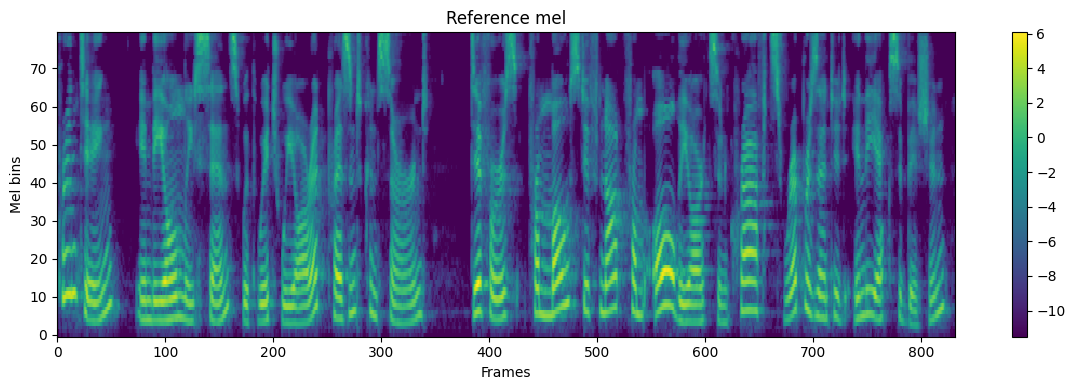

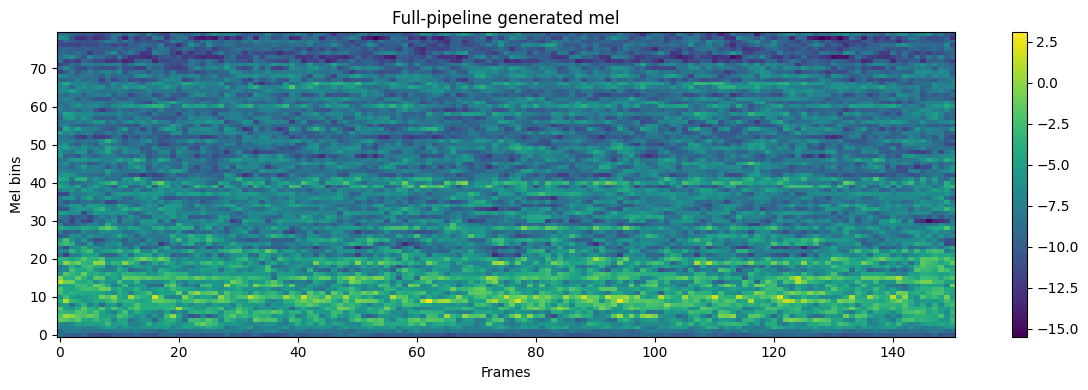

In [ ]:
train_item = items[0]
reference_mel = train_item["mel_raw"]
reference_audio = load_reference_audio(train_item, config)

generated_mel_norm, predicted_durations = model.synthesize(
    train_item["text"],
    tokenizer,
    noise_levels=noise_levels,
    temperature=0.1,
)

generated_mel = denormalize_mel(generated_mel_norm).numpy()
print("Predicted total frames:", int(predicted_durations.sum()))
print("First predicted durations:", predicted_durations[:20].tolist())

plot_mel(reference_mel, "Reference mel")
plot_mel(generated_mel, "Full-pipeline generated mel")


## Listening Comparison

Two signals are compared here:

- `expected` is the reference signal
- `obtained` is the reconstructed signal produced by the full pipeline

The reconstruction stage is intentionally simple, so the resulting sound is rougher than the reference. The more important comparison here is rhythm, pauses, and overall phrase structure.


In [ ]:
generated_audio = log_mel_to_audio(generated_mel, config, n_iter=48)

show_audio_player(reference_audio, config.sample_rate, "Expected audio")
show_audio_player(
    generated_audio, config.sample_rate, "Obtained audio from full pipeline"
)

NameError: name 'log_mel_to_audio' is not defined

## Open Prompt

In this block, you can enter an arbitrary phrase and immediately get:

- a generated spectral representation
- a reconstructed audio preview

This is the free-form pass for text that was not part of the observed pairs.


In [ ]:
train_item["text"]

'printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the exhibition'

In [ ]:
custom_text = widgets.Textarea(
    value="this is a simple test sentence",
    description="Text:",
    layout=widgets.Layout(width="100%", height="100px"),
)
temperature_slider = widgets.FloatSlider(
    value=0.1,
    min=0.0,
    max=0.5,
    step=0.05,
    description="Temp:",
    continuous_update=False,
)
generate_button = widgets.Button(
    description="Generate",
    button_style="success",
    icon="play",
)
custom_output = widgets.Output()


def generate_from_custom_text(_):
    text = normalize_text(custom_text.value)
    with custom_output:
        clear_output(wait=True)

        if not text:
            print("Enter non-empty text.")
            return

        generated_mel_norm, predicted_durations = model.synthesize(
            text,
            tokenizer,
            noise_levels=noise_levels,
            temperature=float(temperature_slider.value),
        )

        generated_mel = denormalize_mel(generated_mel_norm).numpy()
        generated_audio = log_mel_to_audio(generated_mel, config, n_iter=48)

        print("Input text:", text)
        print("Predicted total frames:", int(predicted_durations.sum()))
        print("First predicted durations:", predicted_durations[:20].tolist())
        plot_mel(generated_mel, "Generated mel for custom text")
        show_audio_player(generated_audio, config.sample_rate, "Generated audio")


generate_button.on_click(generate_from_custom_text)

display(
    widgets.VBox(
        [
            custom_text,
            temperature_slider,
            generate_button,
            custom_output,
        ]
    )
)

## Closing Note

After optimization, the system can turn text into a spectral sequence and reconstruct an audible result from it. The sound remains rough by design, but the full workflow is visible end to end and suitable for demonstration and inspection.
